In [1]:
from SPARZ import SPARZIP, SPARUNZIP
import os
from tqdm import tqdm


In [ ]:
# Paths for input files
path1 = '/Users/laurabreimann/Desktop/DNA-PAINT_raw/RawFramesforTraining_P5-IS_20pM.tif'
#path2 = '/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/sequence-as-stack-MT0.N1.HD-BP-250.tif'

stem= 'PAINT'

# Define ranges for grid search
kernel_sizes =  range(11, 24, 4) #  5, 7, 9, 11 
rel_thresholds = [0.05, 0.25, 0.45, 0.65]  # 0.35, 0.45, 0.55, 0.65
compression_levels = [0, 1, 2, 3]  # 0, 1, 2, 3


# Extract base filenames without extension
base_filename1 = os.path.splitext(os.path.basename(path1))[0]
#base_filename2 = os.path.splitext(os.path.basename(path2))[0]


# Total number of iterations for progress bar
total_iterations = len(kernel_sizes) * len(rel_thresholds) * len(compression_levels)

In [ ]:
# Iterate over all combinations of parameters
with tqdm(total=total_iterations, desc="Grid Search Progress", unit="iteration") as pbar: # Initialize tqdm progress bar
    for kernel_size in kernel_sizes:
        for rel_thresh in rel_thresholds:
            for compression_level in compression_levels:
                # Create output paths based on parameters
                output_path = f'/Users/laurabreimann/Desktop/DNA-PAINT_2/sparz_k{kernel_size}_rt{int(rel_thresh*100)}_lev{compression_level}'
                uncompressed_path = os.path.join(output_path, 'uncompressed')
                os.makedirs(uncompressed_path, exist_ok=True)

                # SPARZIP
                z = SPARZIP(path1, stem, output_path, relative_threshold = rel_thresh, kernel_size =kernel_size)
                z.run(codec='x265', compression_level=compression_level)

                # Output files for SPARUNZIP
                path_sparse_bp1 = os.path.join(output_path, f'{base_filename1}.npz')
                #path_sparse_bp2 = os.path.join(output_path, f'{base_filename2}.npz')
                mp4_1 = os.path.join(output_path, f'{base_filename1}_compression_level_{compression_level}.mp4')
                #mp4_2 = os.path.join(output_path, f'{base_filename2}_compression_level_{compression_level}.mp4')

                # SPARUNZIP
                u= SPARUNZIP(path_sparse_bp1= path_sparse_bp1,
                            path_encoded_bp1= mp4_1,
                            stem= stem,
                            output_path= uncompressed_path,
                            #path_sparse_bp2= path_sparse_bp2,
                            #path_encoded_bp2= mp4_2,
                            use_roi = True,
                            chunk_size = 10) 
                u.run()

                # Update progress bar
                pbar.update(1)



# Biplane PSF simulation for figure

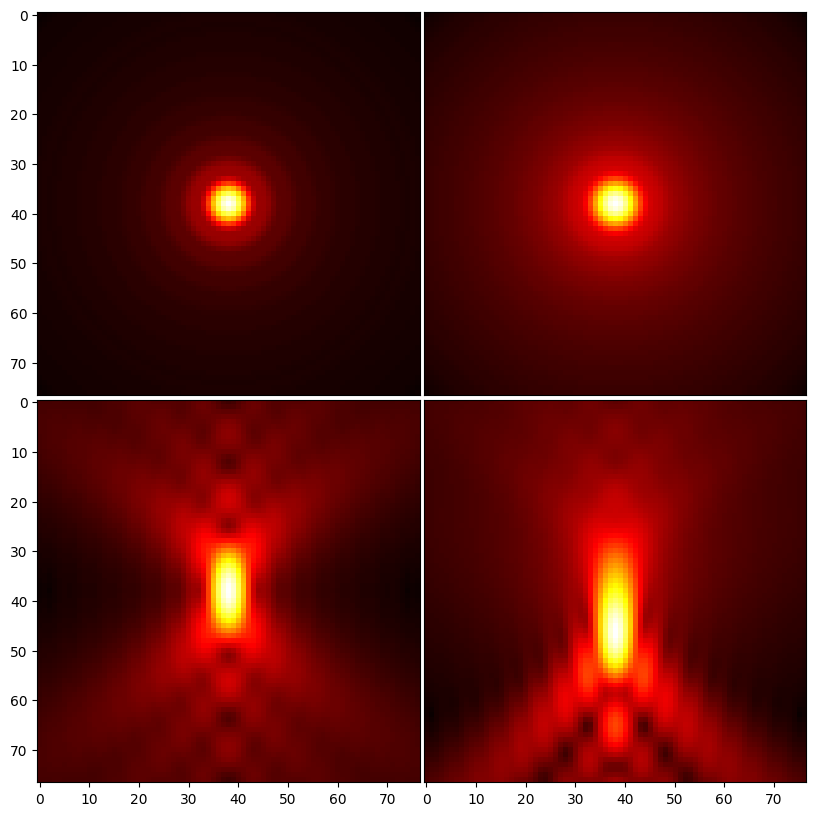

In [13]:
import psfmodels as psfm
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm

# Generate centered PSF with a point source at `pz` microns from coverslip
# In-focus PSF
psf_in_focus = psfm.make_psf(77, 77, dxy=0.05, dz=0.05, pz=0)

# Out-of-focus PSF
psf_out_of_focus = psfm.make_psf(77, 77, dxy=0.05, dz=0.05, pz=10)  # Adjust pz for out-of-focus condition

# Plot the results
fig, axs = plt.subplots(2, 2, figsize=(8, 8))

# XY View - In Focus
axs[0, 0].imshow(psf_in_focus[38], norm=PowerNorm(gamma=0.4), cmap='hot')
#axs[0, 0].set_title('Biplane 1 - XY View')
#Remove ticks
axs[0, 0].set_xticks([])

# XY View - Out of Focus
axs[0, 1].imshow(psf_out_of_focus[38], norm=PowerNorm(gamma=0.4), cmap='hot')
#axs[0, 1].set_title('Biplane 2 - XY View')
axs[0, 1].set_xticks([])
axs[0, 1].set_yticks([])

# ZX View - In Focus
axs[1, 0].imshow(psf_in_focus[:, 38], norm=PowerNorm(gamma=0.4), cmap='hot')
#axs[1, 0].set_title('Biplane 1 - ZX View')

# ZX View - Out of Focus
axs[1, 1].imshow(psf_out_of_focus[:, 38], norm=PowerNorm(gamma=0.4), cmap='hot')
#axs[1, 1].set_title('Biplane 2 - ZX View')
axs[1, 1].set_yticks([])


plt.tight_layout(pad=.1)
plt.savefig('/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/biplane_PSF.png')
plt.show()


# Plot gird search overview

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import re
import cv2
from PIL import Image, ImageSequence
import av
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.gridspec as gridspec


In [ ]:
# Define the parameters used in grid search
kernel_sizes = list(range(5, 12, 2))  # 5, 7, 9, 11
rel_thresholds = [0.35, 0.45, 0.55, 0.65]  # 0.35, 0.45, 0.55, 0.65
compression_levels = [0, 1, 2, 3]  # 0, 1, 2, 3


In [ ]:
# Reconstruction of the full array from the sparse data
def reconstruct_array(data):
    shape = tuple(data['shape'])
    fill_value = data['fill_value']
    coords = data['coords']
    sparse_data = data['data']

    full_array = np.full(shape, fill_value)
    for i, coord in enumerate(zip(*coords)):
        full_array[coord] = sparse_data[i]
    return full_array


# Load and plot the npz files
def load_and_plot_npz_files(folder_path, compression_level=0):
    # Double the number of columns to accommodate two images per condition
    fig, axs = plt.subplots(len(kernel_sizes), len(rel_thresholds) * 2, figsize=(15, 10))

    for root, dirs, files in os.walk(folder_path):
        for dir in dirs:
            kernel_size, rel_threshold, comp_level = extract_parameters(dir)

            if comp_level == compression_level:
                if kernel_size in kernel_sizes and rel_threshold in rel_thresholds:
                    file_paths = ['sequence-as-stack-MT0.N1.HD-BP-250.npz', 'sequence-as-stack-MT0.N1.HD-BP+250.npz'] # this is for the microtubule data
                    for index, file_name in enumerate(file_paths):
                        file_path = os.path.join(root, dir, file_name)
                        if os.path.exists(file_path):
                            data = np.load(file_path)
                            full_array = reconstruct_array(data)
                            selected_image = full_array[25]

                            # Find the correct subplot
                            i = kernel_sizes.index(kernel_size)
                            j = rel_thresholds.index(rel_threshold) * 2 + index

                            # Plot the selected image
                            axs[i, j].imshow(selected_image, cmap='gray', interpolation='none')
                            axs[i, j].axis('off')

                            # Set title for the first image of the pair
                            if index == 0:
                                axs[i, j].set_title(f'k{kernel_size} thr{rel_threshold}')

    plt.tight_layout()

      # Save the plot as a PDF
    plt.savefig('/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/npz_profiles_240122.pdf', format='pdf')  

    plt.show()

# Extract the parameters from the folder name after the grid search
def extract_parameters(folder_name):
    match = re.search(r'k(\d+)_rt(\d+)_lev(\d+)', folder_name)
    if match:
        kernel_size = int(match.group(1))
        rel_threshold = float(f"0.{match.group(2)}")
        compression_level = int(match.group(3))
        return kernel_size, rel_threshold, compression_level
    else:
        return None, None, None

In [ ]:

main_folder_path = "/Users/laurabreimann/Desktop/microtubule_data"
# Load and plot
load_and_plot_npz_files(main_folder_path)

# Plot compressed video frames 

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import imageio.v2 as imageio
import numpy as np
import ffmpeg
from reader import imread as vimread
from dask import array as da

In [ ]:
def normalize_image_16bit_to_8bit(img, min_val, max_val):
    # Ensure the image is in 16-bit format
    img_16bit = img.astype(np.uint16)
    
    # Normalize the image based on the min and max values
    img_norm = (img_16bit - min_val) / (max_val - min_val) * 65535
    img_norm = np.clip(img_norm, 0, 65535)  # Ensure the values are within 16-bit range

    # Scale down to 8-bit for display
    img_norm_8bit = (img_norm / 256).astype(np.uint8)
    return img_norm_8bit

def read_tiff_frame(image_path, frame_number):
    with Image.open(image_path) as img:
        # Seek to the specified frame
        img.seek(frame_number)
        frame = np.array(img)
        if frame.ndim == 2:  # If the image is grayscale
            return frame
        else:  # If the image is colored, convert to grayscale
            return cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)


In [ ]:

# Frame number to extract
frame_number = 25  # Example frame number
tiff_frame_number = 25

# Paths to your video files
video_paths = [
   ["/Users/laurabreimann/Desktop/microtubule_data/sparz_k5_rt35_lev0/sequence-as-stack-MT0.N1.HD-BP+250_compression_level_0.mp4",
    "/Users/laurabreimann/Desktop/microtubule_data/sparz_k5_rt35_lev0/sequence-as-stack-MT0.N1.HD-BP-250_compression_level_0.mp4"],
    ["/Users/laurabreimann/Desktop/microtubule_data/sparz_k5_rt35_lev1/sequence-as-stack-MT0.N1.HD-BP+250_compression_level_1.mp4",
    "/Users/laurabreimann/Desktop/microtubule_data/sparz_k5_rt35_lev1/sequence-as-stack-MT0.N1.HD-BP-250_compression_level_1.mp4"],
    ["/Users/laurabreimann/Desktop/microtubule_data/sparz_k5_rt35_lev2/sequence-as-stack-MT0.N1.HD-BP+250_compression_level_2.mp4", 
    "/Users/laurabreimann/Desktop/microtubule_data/sparz_k5_rt35_lev2/sequence-as-stack-MT0.N1.HD-BP-250_compression_level_2.mp4"], 
     ["/Users/laurabreimann/Desktop/microtubule_data/sparz_k5_rt35_lev3/sequence-as-stack-MT0.N1.HD-BP+250_compression_level_3.mp4", 
     "/Users/laurabreimann/Desktop/microtubule_data/sparz_k5_rt35_lev3/sequence-as-stack-MT0.N1.HD-BP-250_compression_level_3.mp4"]
]


# Read the original TIFF images
original_image_path1 = "/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/testing_sparz/simulated_tubulin/sequence-as-stack-MT0.N1.HD-BP+250_t.tif"
original_image1 = read_tiff_frame(original_image_path1, tiff_frame_number)

original_image_path2 = "/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/testing_sparz/simulated_tubulin/sequence-as-stack-MT0.N1.HD-BP-250_t.tif"
original_image2 = read_tiff_frame(original_image_path2, tiff_frame_number)

# Find min and max pixel values from compression level 0 images
min_val = original_image2.min()
print(min_val)
max_val = original_image2.max()
print(max_val)

# Normalize original_image1 to the same range as original_image2
original_image1_normalized = normalize_image_16bit_to_8bit(original_image1, min_val, max_val)
#original_image2_normalized = normalize_image(original_image2, min_val, max_val)



In [ ]:
# Number of rows and columns for the plot
num_rows = len(video_paths) +1 
num_cols = 2  # Two videos per compression level

fig = plt.figure(figsize=(15, num_rows * 5))  # Adjust the figure size as needed

# Create a gridspec layout with 1 column for the color bar
gs = gridspec.GridSpec(num_rows, num_cols + 1, width_ratios=[1, 1, 0.05], wspace=0.3, hspace=0.3)


# Add the first original image as the first subplot
plt.subplot(num_rows, num_cols, 1)
plt.imshow(original_image1_normalized, cmap='magma',  interpolation='none')
plt.title("Original Image 1")
plt.axis('off')

# Add the second original image as the second subplot
plt.subplot(num_rows, num_cols, 2)
plt.imshow(original_image2, cmap='magma',  interpolation='none')
plt.title("Original Image 2")
plt.axis('off')


for i, level_paths in enumerate(video_paths):
    for j, path in enumerate(level_paths):
        # Use vimread to read the entire video as a dask array
        video_dask_array = vimread(path, dtypes='uint16')
        
        # Index the dask array to get the frame you want
        frame_dask = video_dask_array[frame_number]
        
        # Compute the dask array to get the NumPy array of the frame
        frame_data = frame_dask.compute()
        
        # Normalize the frame if it was successfully extracted
        # Ensure you're using a normalization function that's appropriate for 16-bit data
        frame_normalized = normalize_image_16bit_to_8bit(frame_data, np.min(frame_data), np.max(frame_data))
        
        # Add subplot for the compressed frame
        plt.subplot(num_rows, num_cols, (i + 1) * num_cols + j + 1)
        plt.imshow(frame_normalized, cmap='magma', interpolation='none')
        plt.title(f"Compression Level {i}, Video {j + 1}")
        plt.axis('off')



# Select the last column of the first row for the color bar
cbar_ax = fig.add_axes([0.9, 0.15, 0.015, 0.7])  # Adjust these values as necessary

# Create a color bar with the specified axes
norm = Normalize(vmin=min_val, vmax=max_val)
sm = ScalarMappable(cmap='magma', norm=norm)
sm.set_array([])

# Add the color bar to the figure
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Intensity')

# Adjust layout
fig.subplots_adjust(wspace=0.4, hspace=0.4)  # Adjust white space to your liking


# Adjust the layout and save
plt.tight_layout()
plt.savefig('/Users/laurabreimann/Documents/Postdoc/Colabs/Compression/Figures/mp4_profiles_240122.pdf', format='pdf', bbox_inches='tight')
plt.show()

# SSIM vs file size